# Data Set-

Kaggle - https://www.kaggle.com/datasets/msambare/fer2013
The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centred and occupies about the same amount of space in each image.

The task is to categorize each face based on the emotion shown in the facial expression into one of seven categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral)


In [ ]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"parasmaniyogi","key":"c8de98bd2af87e1420261ab8020b05bf"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d msambare/fer2013

In [ ]:
!unzip /content/fer2013.zip -d /content/

# Installing Packages

---



In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import imghdr
import tensorflow as tf
from PIL import Image
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.applications import VGG16, ResNet50V2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import plot_model

/tmp/ipykernel_1236/3330320704.py:7: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


# Setting up Data Directory

In [ ]:
# Define project name
project_name = 'FER_2013_Emotion_Dection_using_Transfer_Learning'

# List models
model_names = [
    'Custom_CNN_From_scratch',
    'Custom_CNN_With_Augmentation',
    'VGG16_Transfer_Learning',
    'ResNet50_Transfer_Learning'
]

base_dir = '/content/'

# Create the Project Directory
project_dir = os.path.join(base_dir,project_name)
os.makedirs(project_dir,exist_ok=True)

# Create a subdirectory for each model
for each_model in model_names:
  model_dir = os.path.join(project_dir,each_model)
  os.makedirs(model_dir,exist_ok=True)
  # Example subdirectories for model-related files
    # os.makedirs(os.path.join(model_dir, 'checkpoints'), exist_ok=True)
    # os.makedirs(os.path.join(model_dir, 'logs'), exist_ok=True)
    # os.makedirs(os.path.join(model_dir, 'saved_models'), exist_ok=True)

print(f'Project directory structure created at: {project_dir}')


Project directory structure created at: /content/FER_2013_Emotion_Dection_using_Transfer_Learning


# Data Cleaning

In [ ]:
# Define the list of acceptable image extensions
image_exts = ['jpeg','jpg','png']

# path to the directory containing image classes and possibly other nested subdirectories
data_dir = '/content/train'

# Walk through all directories and files in the dataset
for root,dirs,files in os.walk(data_dir):
  for file in files:
    # Construct the path to the current file
    file_path = os.path.join(root,file)

    try:
      # check the file type of the current file
      file_type = imghdr.what(file_path)

      # If the file extensions is not in the allowed list, remove it
      if file_type not in image_exts:
        print(f'Image not in ext list {file_path}')
        os.remove(file_path)
      else:
        # Proceed to process the image if needed. for example, reading it with OpenCV
        img = cv2.imread(file_path)

    except Exception as e:
      # Print out the issue and the path of the problematic file
      print(f"Issue with file {file_path}.Error: {e}")
      # Optionally, remove files that cause exceptions
      os.remove(file_path)

# Data Analysis

In [ ]:
# Define a function to count the number of files (assumed to be images for this context) for each subdirectory in a given directory.
# The function returns a DataFrame with these counts, indexed by a specified set name (e.g., 'train' or 'test').
def count_files_in_subdirs(directory, set_name):
    # Initialize an empty dictionary to hold the count of files for each subdirectory.
    counts = {}

    # Iterate over each item in the given directory.
    for item in os.listdir(directory):
        # Construct the full path to the item.
        item_path = os.path.join(directory, item)

        # Check if the item is a directory.
        if os.path.isdir(item_path):
            # Count the number of files in the subdirectory and add it to the dictionary.
            counts[item] = len(os.listdir(item_path))

    # Convert the counts dictionary to a DataFrame for easy viewing and analysis.
    # The index of the DataFrame is set to the provided set name.
    df = pd.DataFrame(counts, index=[set_name])
    return df

# Paths to the training and testing directories.
train_dir = '/content/train'
test_dir = '/content/test'

# Count the files in the subdirectories of the training directory and print the result.
train_count = count_files_in_subdirs(train_dir, 'train')
print(train_count)

# Count the files in the subdirectories of the testing directory and print the result.
test_count = count_files_in_subdirs(test_dir, 'test')
print(test_count)


       disgust   sad  fear  happy  angry  surprise  neutral
train      436  4830  4097   7215   3995      3171     4965
      disgust   sad  fear  happy  angry  surprise  neutral
test      111  1247  1024   1774    958       831     1233


In [ ]:
train_count

,disgust,sad,fear,happy,angry,surprise,neutral
train,436,4830,4097,7215,3995,3171,4965


In [ ]:
train_count.transpose()

,train
disgust,436
sad,4830
fear,4097
happy,7215
angry,3995
surprise,3171
neutral,4965


<Axes: >

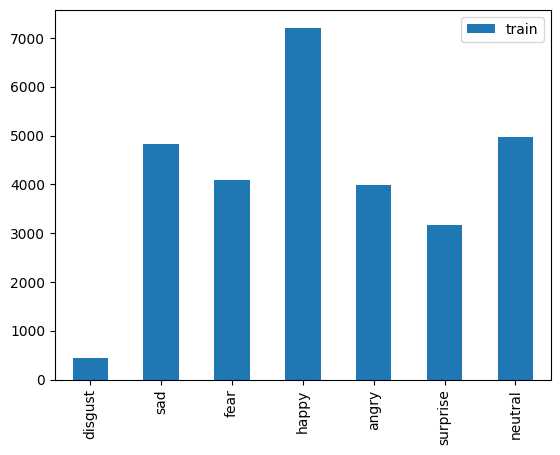

In [ ]:
train_count.transpose().plot(kind='bar')

<Axes: >

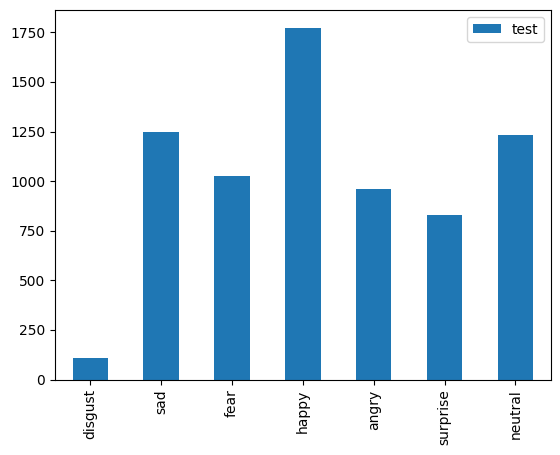

In [ ]:
test_count.transpose().plot(kind='bar')

# Plotting one image from each emotion


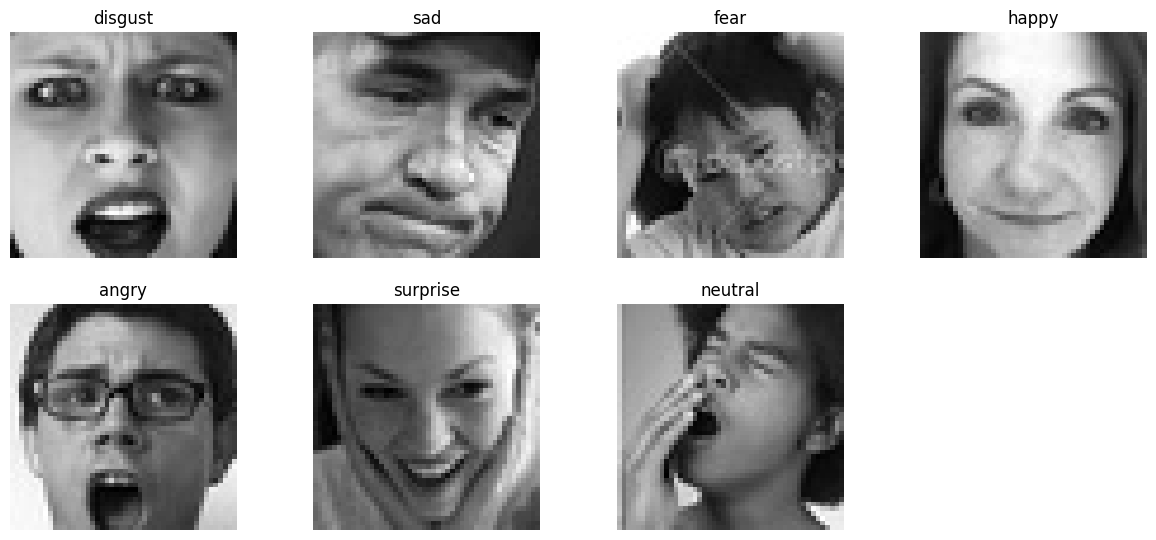

In [ ]:
emotions = os.listdir(train_dir)          # Get list of emotion class folders from training directory
plt.figure(figsize=(15,10))

for i, emotion in enumerate(emotions, 1): # Loop through each emotion with an index starting from 1
    folder = os.path.join(train_dir, emotion)  # Create full path to the emotion folder
    img_path = os.path.join(folder, os.listdir(folder)[42])  # Select the 43rd image from the folder
    img = plt.imread(img_path)            # Read the selected image into an array
    plt.subplot(3, 4, i)                  # Create a subplot in a 3x4 grid at position i
    plt.imshow(img, cmap='gray')          # Display the image in grayscale
    plt.title(emotion)
    plt.axis('off')


# Plotting random images from given directory

In [ ]:
def plot_images_from_directory(directory_path,class_name,num_images = 9):
    # Retrive list of all file names in the directory
    image_filenames = os.listdir(directory_path)

    # If there are fewer images than requested, we'll just show them all
    if len(image_filenames) < num_images:
      print(f"only found {len(image_filenames)} images in {directory_path} displaying them all.")
      num_images = len(image_filenames)

    # Randomly select 'num_images' number file names
    selected_images = random.sample(image_filenames,num_images)

    # Plotting the images
    fig,axes = plt.subplots(3,3,figsize=(5,5))
    axes = axes.ravel()   # axes.ravel() flattens the grid into a 1D array for easy indexing.

    for i, image_file in enumerate(selected_images):
        image_path = os.path.join(directory_path,image_file)
        # image = Image.open(image_path)
        image = load_img(image_path)
        axes[i].imshow(image)
        axes[i].set_title(f"Image : {class_name}")
        axes[i].axis('off')  # Hide the axis

    plt.tight_layout()
    plt.show()


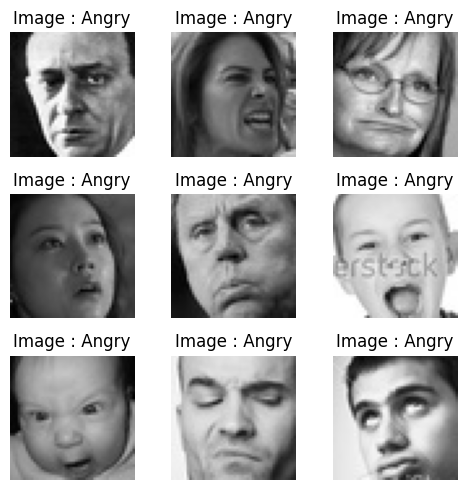

In [ ]:
# Placeholder for directory path
angry_directory_path = '/content/train/angry'
plot_images_from_directory(angry_directory_path,class_name='Angry')

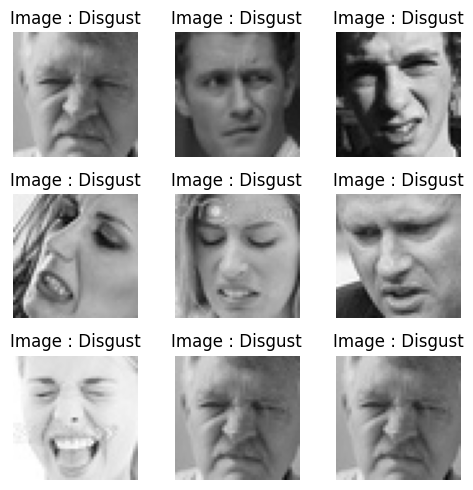

In [ ]:
# Placeholder for directory path
disgust_directory_path = '/content/train/disgust'
plot_images_from_directory(disgust_directory_path,class_name='Disgust')

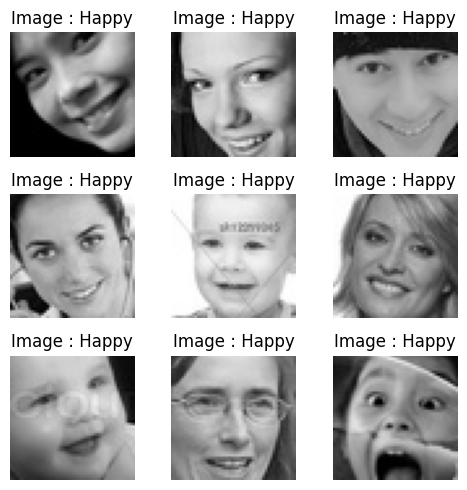

In [ ]:
# Placeholder for the directory path
happy_directory_path = '/content/train/happy'
plot_images_from_directory(happy_directory_path, class_name = 'Happy')

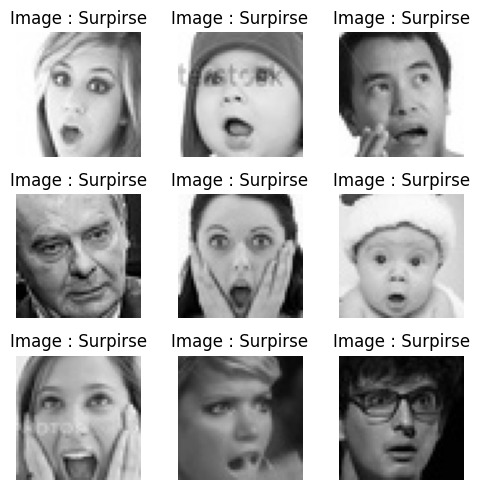

In [ ]:
# Placeholder for the directory path
surpirse_directory_path = '/content/train/surprise'
plot_images_from_directory(surpirse_directory_path, class_name = 'Surpirse')

# Checking Shaper and Channels

In [ ]:
image = '/content/train/angry/Training_10118481.jpg'

img = cv2.imread(image) # cv2 Default load in color format.

# If the image is loaded successful, print its pixel values
if image is not None:
  # print(img)
  print("Shape : ",img.shape)
else:
  print("The image could not be loaded. Please check the path and file permissions.")

Shape :  (48, 48, 3)


### Some Note
* In initailly over image is grey scale i.e. (48,48,1)
* but now it is showing (48,48,3) because bydefault cv2 all images in `bgr` ( Blue, Green, Red ) mode.
* cv2 create a dummy image in which the 2 extra channels also have the same pixel value as channel 1.
* So we need to read the images in greyscsle format.

In [ ]:

image_path = '/content/train/angry/Training_10118481.jpg'

img = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE) # cv2 Default load in color format.

# If the image is loaded successful, print its pixel values
if image is not None:
  # print(img)
  print("Shape : ",img.shape)
else:
  print("The image could not be loaded. Please check the path and file permissions.")

Shape :  (48, 48)


# **Model 1 : Custom CNN From Scratch**

# Initializing the ImageGenerators

In [ ]:
# Define path to the train and test directories
train_data_dir = '/content/train'
test_data_dir = '/content/test'

In [ ]:
# Set some Parameters
img_width,img_height = 48,48 # size of image
batch_size = 64
epochs = 20
num_classes = 7 # Update this based on the number of your classes

In [ ]:
# Rescale the pixel values (0-255) to the [0,1] interval
data_generator = ImageDataGenerator(rescale = 1./255,validation_split=0.2)

# Automaticaly retrive images and their classes for train and validation sets
train_generator = data_generator.flow_from_directory(
    train_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',  # multiclass (7-classes)
    color_mode = 'grayscale',
    subset = 'training'
)


validation_generator = data_generator.flow_from_directory(
    train_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',  # multiclass (7-classes)
    color_mode = 'grayscale',
    subset = 'validation'
)


test_generator = data_generator.flow_from_directory(
    test_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',  # multiclass (7-classes)
    color_mode = 'grayscale'
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
# Accessing class labels for the training data
train_class_labels = train_generator.class_indices
print("Training class labels:", train_class_labels)

# Accessing class labels for the validation data
validation_class_labels = validation_generator.class_indices
print("Validation class labels:", validation_class_labels)

# Accessing class labels for the validation data
test_class_labels = test_generator.class_indices
print("Validation class labels:", test_class_labels)

Training class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Validation class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Validation class labels: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


### Initialising the CNN

In [ ]:
# Initialising the CNN
model = Sequential()

# Adding convolutional layers with activations on the same line for clarity
model.add(Conv2D(32, kernel_size=(3, 3),kernel_initializer="glorot_uniform", padding='same', input_shape=(img_width, img_height, 1)))
model.add(Activation('relu'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

model.add(Conv2D(128, kernel_size=(3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01)))
model.add(Activation('relu'))
model.add(Conv2D(256, kernel_size=(3, 3), kernel_regularizer=regularizers.l2(0.01)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


model.add(Conv2D(512, kernel_size=(3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01)))
model.add(Activation('relu'))
model.add(Conv2D(512, kernel_size=(3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening and adding dense layers
model.add(Flatten())
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes))
model.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 1. Conv2D(32, kernel_size=(3,3), padding='same', input_shape=(img_width, img_height, 1))

**Purpose:** Feature extraction (edges, textures, patterns)

- **32 filters** → the network learns 32 different feature maps  
- **Kernel size (3×3)** → looks at small local regions of the image  
- **`padding='same'`** → output feature map has the same spatial size as the input  
- **`input_shape=(img_width, img_height, 1)`**
  - Width × Height image  
  - **1 channel** → grayscale image  
- **`kernel_initializer='glorot_uniform'`**
  - Smart weight initialization to help stable training  

 *This layer learns low-level features like edges and corners.*

---

## 2. Activation('relu')

**Purpose:** Introduce non-linearity

- ReLU = `max(0, x)`  
- Removes negative values  
- Helps the network learn complex patterns  
- Speeds up training and avoids vanishing gradients  

---

## 3. Conv2D(64, kernel_size=(3,3), padding='same')

**Purpose:** Learn more complex features

- **64 filters** → more feature maps than the previous layer  
- Builds on earlier features *(edges → shapes → patterns)*  
- Uses **3×3 filters** with **same padding**  

 *Deeper layers capture higher-level visual information.*

---

## 4. Activation('relu')

- Adds non-linearity  
- Keeps positive activations only  

---

## 5. BatchNormalization()

**Purpose:** Stabilize and speed up training

- Normalizes activations in the batch  
- Reduces internal covariate shift  
- Allows higher learning rates  
- Acts as a mild regularizer  

 *Makes training more stable and less sensitive to initialization.*

---

## 6. MaxPooling2D(2,2)

**Purpose:** Downsampling

- **Pool size:** 2×2  
- Reduces spatial dimensions by half  
- Keeps the strongest activation in each region  
- Reduces computation and overfitting  

 *Makes features more translation-invariant.*

---

## 7. Dropout(0.25)

**Purpose:** Prevent overfitting

- Randomly drops **25% of neurons** during training  
- Forces the network to not rely on specific neurons  
- Improves generalization  

 *Active only during training, not during inference.*


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 11, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,046,535 (65.03 MB)

 Trainable params: 17,044,871 (65.02 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

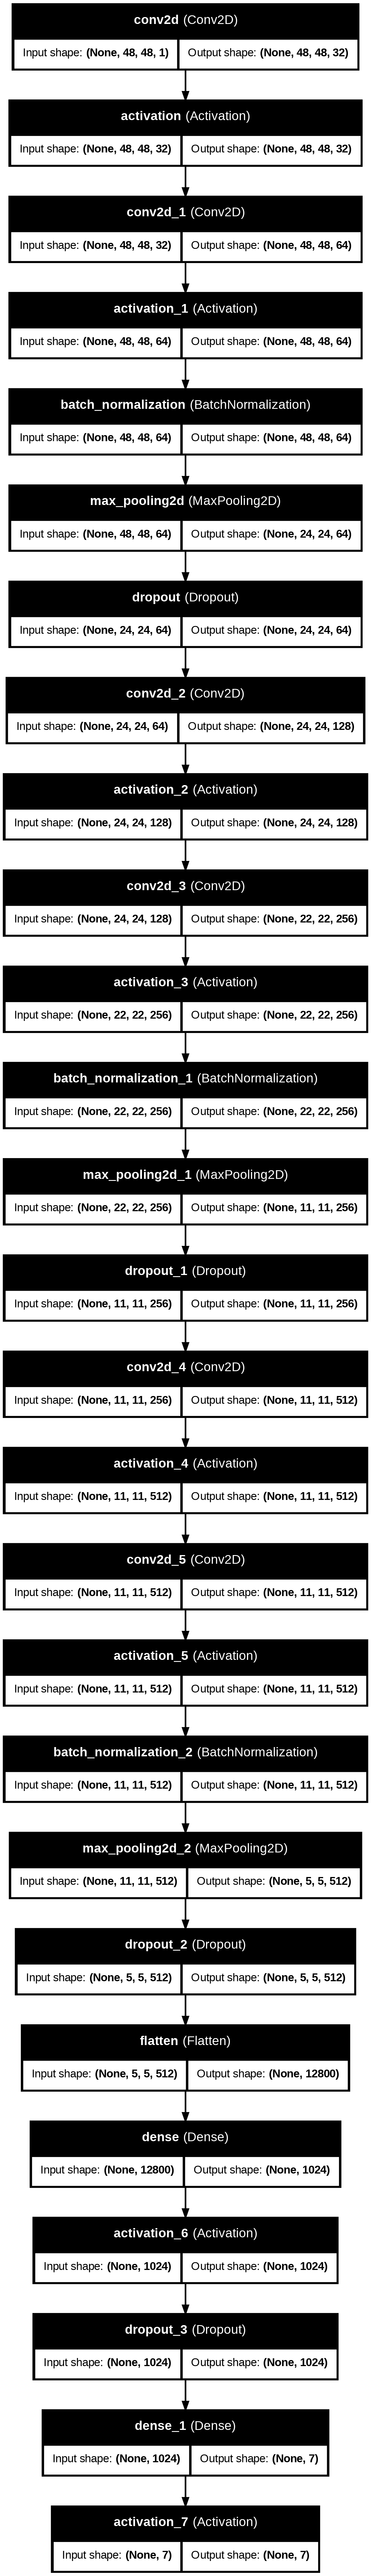

In [ ]:
plot_model(model, to_file = '/content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_From_scratch/Architecture.png',
           show_shapes=True, show_layer_names=True)

# Understanding Callbacks

In [ ]:
# File path for the model checkpoint
cnn_path = '/content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_From_scratch'
name = 'Custom_CNN_model.keras'
chk_path = os.path.join(cnn_path,name)
chk_path

'/content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_From_scratch/Custom_CNN_model.keras'

### `ModelCheckpoint :` ModelCheckpointis a callback that saves the CNN model during training whenever the monitored metric shows improvement.

* **Purpose**: Ensures that only the best-performing CNN model is saved.

In [ ]:
# Callback to save the model checkpoint
checkpoint = ModelCheckpoint(filepath=chk_path,      # Where the model is saved
                             save_best_only = True,  # Saves only when performance improves
                             verbose = 1,            # Displays a message when saving
                             mode = 'min',           # Lower value is better (used for loss)
                             monitor = 'val_loss')   # Metric to track (e.g., val_loss, val_accuracy)

In [ ]:
# Callback for early stopping
earlystop = EarlyStopping(monitor='val_loss',  # Metric to watch
                          min_delta=0,         # Minimum change to count as improvement
                          patience = 3,        # Number of epochs to wait before stopping after no improvement
                          verbose = 1,         # Displays a message when training stops
                          restore_best_weights = True)  # Restores weights from the best epoch

In [ ]:
# Callback to reduce learning
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss',  # Metric to watch
                              factor = 0.2,          # Multiplier for learning rate (new LR = old LR × factor)
                              patience = 6,          # Number of epochs to wait before reducing LR
                              verbose = 1,           # Displays messages when LR is reduced

                              min_delta = 0.0001)    # Minimum change to count as improvement

In [ ]:

# Callback to log training data to a CSV file
csv_logger = CSVLogger(os.path.join(cnn_path,'training.log'))

In [ ]:
# Aggregating all callbacks into a list
callbacks = [checkpoint,earlystop,reduce_lr,csv_logger]

# Calculating Steps for epoch

In [ ]:
train_generator.samples

22968

In [ ]:
train_steps_per_epoch = train_generator.samples // train_generator.batch_size + 1
validation_steps_per_epoch = validation_generator.samples // validation_generator.batch_size + 1
test_steps_per_epoch = test_generator.samples // test_generator.batch_size + 1

In [ ]:
print("train_steps_per_epoch = ",train_steps_per_epoch)
print("validation_steps_per_epoch = ",validation_steps_per_epoch)
print("test_steps_per_epoch = ",test_steps_per_epoch)

train_steps_per_epoch =  359
validation_steps_per_epoch =  90
test_steps_per_epoch =  113


# Model Training

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch = train_steps_per_epoch,
    epochs = 10,
    validation_data = validation_generator,
    validation_steps = validation_steps_per_epoch,
    callbacks = callbacks
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2358 - loss: 13.3727
Epoch 1: val_loss improved from None to 12.21589, saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_From_scratch/Custom_CNN_model.keras

Epoch 1: finished saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_From_scratch/Custom_CNN_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.2729 - loss: 12.4055 - val_accuracy: 0.1777 - val_loss: 12.2159 - learning_rate: 1.0000e-04
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3443 - loss: 10.6237
Epoch 2: val_loss improved from 12.21589 to 9.16423, saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_From_scratch/Custom_CNN_model.keras

Epoch 2: finished saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_From_scratch/Custom_CNN_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accu

# Plotting Performance Metrics

In [ ]:
def plot_training_history(history):
    """
    Plots the training and validation accuracy and loss.

    Parameters:
    - history: A Keras History object. Contains the logs from the training process.

    Returns:
    - None. Display the matplotlib plots for training/validation accuracy and loss.
    """

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(20, 5))

    # Plot training and validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()

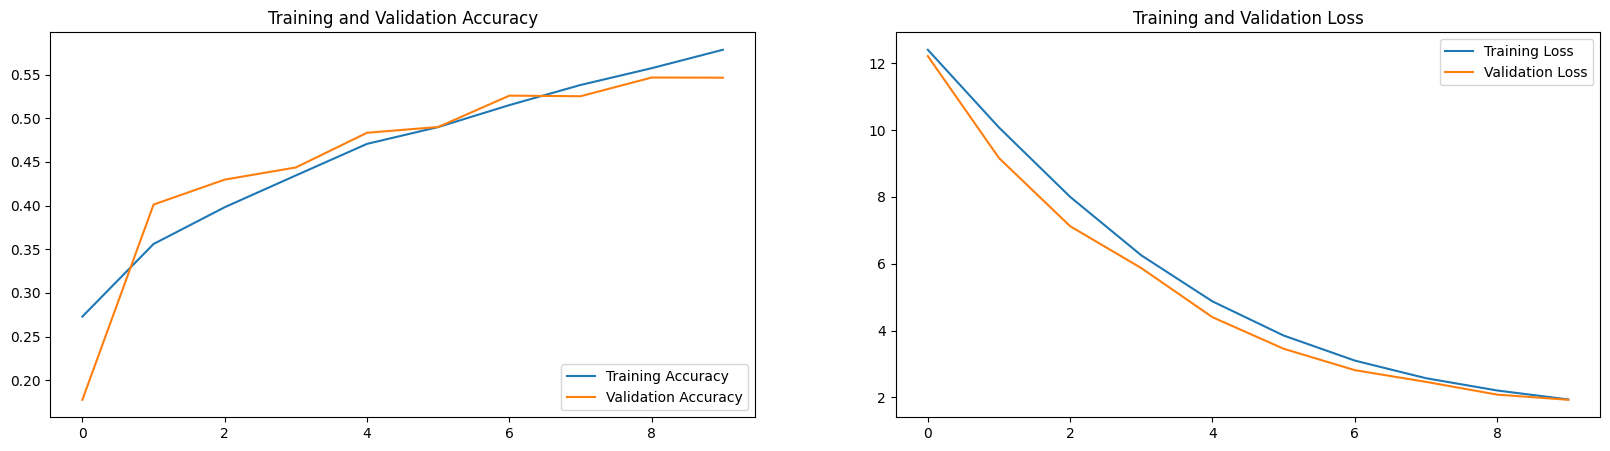

In [ ]:
plot_training_history(history)

# Model Evalution

In [ ]:
train_loss, train_accu = model.evaluate(train_generator)
test_loss,test_accu = model.evaluate(test_generator)

print("Final train accuracy = {:.2f}, validation accuracy = {:.2f}".format(train_accu*100,test_accu*100))

359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.6392 - loss: 1.7204
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.5548 - loss: 1.9189
Final train accuracy = 63.92, validation accuracy = 55.48


# Plotting Confusion Matrix

In [ ]:
class_labels = list(test_generator.class_indices.keys())

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


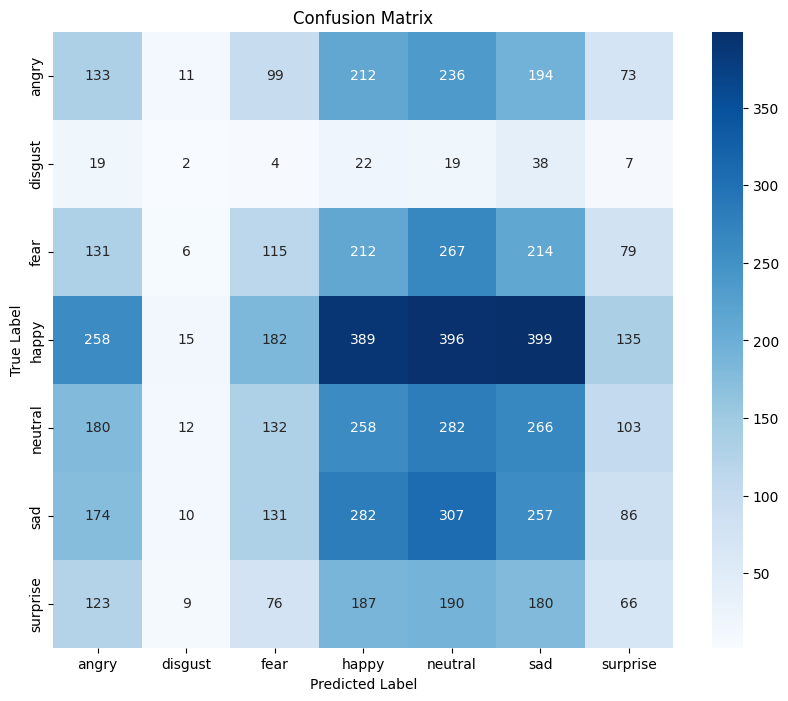

In [ ]:
# Assuming our true_classes and predicted_classes are already defined
true_classes = test_generator.classes
predicted_classes = np.argmax(
    model.predict(test_generator, steps=len(test_generator)),
    axis=1
)

# Generate the confusion matrix
cm = confusion_matrix(true_classes,predicted_classes)

# Ploting with seaborn
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_labels,yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [ ]:
# Printing the classification report
report = classification_report(true_classes,predicted_classes,target_names=class_labels)
print("Classfication Report :\n",report)

Classfication Report :
               precision    recall  f1-score   support

       angry       0.13      0.14      0.13       958
     disgust       0.03      0.02      0.02       111
        fear       0.16      0.11      0.13      1024
       happy       0.25      0.22      0.23      1774
     neutral       0.17      0.23      0.19      1233
         sad       0.17      0.21      0.18      1247
    surprise       0.12      0.08      0.10       831

    accuracy                           0.17      7178
   macro avg       0.15      0.14      0.14      7178
weighted avg       0.17      0.17      0.17      7178



### From the Report....
The model achieved an overall accuracy of 18%, which is only marginally higher than the random baseline of ≈14% for seven classes, indicating limited discriminative capability. Performance varies across emotions, with happy and sad showing comparatively better recognition, while disgust and fear are almost completely misclassified. The low macro and weighted F1-scores highlight poor generalization across classes. These results suggest that the model is underfitting and requires substantial improvements in data balance and model design.

# Making Predictions

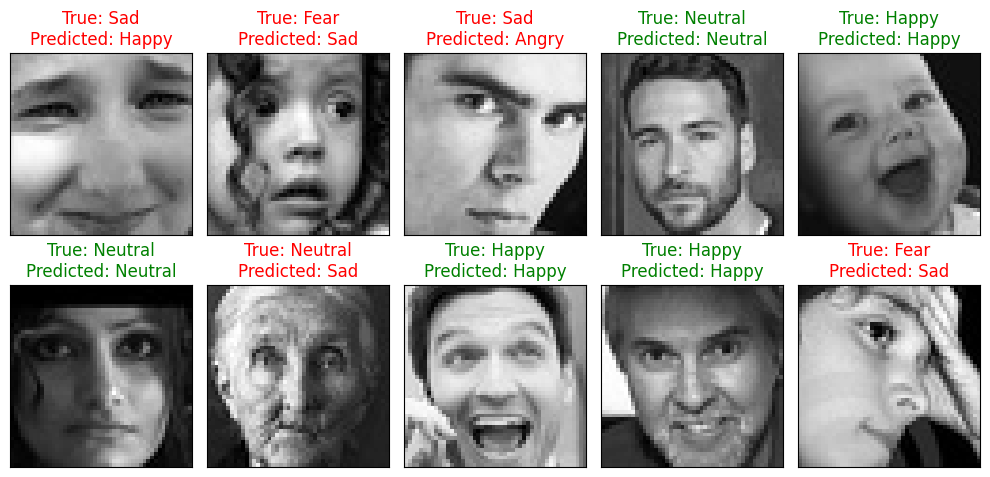

In [ ]:
# Emotion classes for the dataset
Emotion_Classes = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprise']

# Assuming test_generator and model are already defined
batch_size = test_generator.batch_size

# Selecting a random batch from the test generator
Random_batch = np.random.randint(0,len(test_generator)-1)

# Selesting eandom image indices from the batch
Random_Img_Index = np.random.randint(0,batch_size,10)

# Setting up the plot
fig,axes = plt.subplots(nrows=2,ncols=5,figsize=(10,5),
                        subplot_kw={'xticks':[],'yticks':[]})

for i,ax in enumerate(axes.flat):
    # Fetching the random image and its label
    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]
    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]],axis=0)

    # Making a prediction using the model
    Model_Prediction = np.argmax(model.predict(tf.expand_dims(Random_Img,axis=0),verbose=0),axis=1)[0]

     # Displaying the image
    ax.imshow(Random_Img.squeeze(), cmap='gray')  # Assuming the images are grayscale
    # Setting the title with true and predicted labels, colored based on correctness
    color = "green" if Emotion_Classes[Random_Img_Label] == Emotion_Classes[Model_Prediction] else "red"
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[Model_Prediction]}", color=color)

plt.tight_layout()
plt.show()

# **Model 2 : Image Augmentation**

In [ ]:
train_generator

In [ ]:
# Define path to the train and test directories
train_data_dir = '/content/train'
test_data_dir = '/content/test'

# Set Some Parameters
img_width,img_height = 48,48
batch_size = 64
epochs = 10
num_classes = 7

# Initializing the ImageDataGenerator with data augmentation options for the training set
data_generator = ImageDataGenerator(
    rescale = 1./255,         # Rescale the pixel values from [0,255] to [0.1]
    rotation_range = 40,      # Degree range for random rotations
    width_shift_range = 0.2,  # Range (as a fractions of total width) for random horizontal shifts
    height_shift_range = 0.2,  # Range (as a fraction of total height) for random vertical shifts
    shear_range = 0.2,        # Shearing intensity (shear angle in counter-clockwise direction)
    zoom_range = 0.2,         # Range for random zoom
    horizontal_flip = True,   # Randomly flip inputs horizontally
    fill_mode = 'nearest',    # Strategy to fill newly created pixels, which can appear after a rotation or a width/height shift
    validation_split=0.2      # Set the validation split; 20% of the data will be used for validation
)


# Automatically retrieve images and their classes for train and validation sets
train_generator = data_generator.flow_from_directory(
    train_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',
    color_mode = 'grayscale',
    subset = 'training'
)


validation_generator = data_generator.flow_from_directory(
    train_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',
    color_mode = 'grayscale',
    subset = 'validation'
)

test_generator = data_generator.flow_from_directory(
    test_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',
    color_mode = 'grayscale'
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


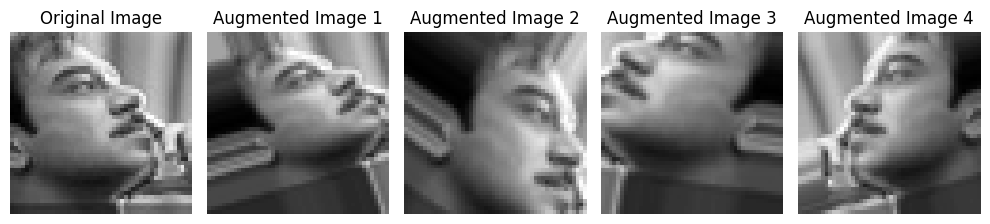

In [ ]:
# Path to a specific image
image_path = '/content/train/angry/Training_10161559.jpg'

# Load and convert the image to an array
img = load_img(image_path,color_mode='grayscale',target_size=(img_width,img_height))
img_array = img_to_array(img)  # converts the image to a numpy array
img_array = img_array.reshape((1,) + img_array.shape) # Reshapes the image to (batch_size,width,height,channels) for the generator

# Setting up the plot
fig,axes = plt.subplots(nrows=1,ncols=5,figsize=(10,4))
# plot the original image first. Since img_array is a 3D array after reshaping, we use [:,:,0]
axes[0].imshow(img_array[0,:,:,0] ,cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')


# Generate and plot augmented images
for i,ax in enumerate(axes.flat[1:]):   # start from the second subplot
      # Generate a batch of augmented images
      aug_iter = data_generator.flow(img_array,batch_size=1)
      aug_img = next(aug_iter)[0]  # Get the first augmented image from the batch

      # Plot the augmented image. We directly use [:,:,0] without an initial batch index
      ax.imshow(aug_img[:,:,0],cmap='gray')
      ax.set_title(f"Augmented Image {i+1}")
      ax.axis('off')
plt.tight_layout()
plt.show()

# Same CNN Model as above

In [ ]:
# Assuming img_width, img_height, and classes are defined. For example:
img_width, img_height = 48, 48
classes = 7

#Initialising the CNN
model = tf.keras.models.Sequential()

# Adding convolutional layers with activations on separate lines
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=(img_width, img_height, 1)))
model.add(tf.keras.layers.Activation('relu'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

model.add(Conv2D(128, kernel_size=(3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01)))
model.add(tf.keras.layers.Activation('relu'))
model.add(Conv2D(256, kernel_size=(3, 3), kernel_regularizer=regularizers.l2(0.01)))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512, kernel_size=(3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01)))
model.add(tf.keras.layers.Activation('relu'))
model.add(Conv2D(512, kernel_size=(3, 3), padding='same', kernel_regularizer=regularizers.l2(0.01)))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening and adding dense layers
model.add(Flatten())
model.add(Dense(1024))
model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(classes))
model.add(tf.keras.layers.Activation('softmax'))

# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# File path for the model checkpoint
cnn_path = '/content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_With_Augmentation'
name = 'Custom_CNN_augmented_model.keras'
chk_path = os.path.join(cnn_path, name)

# Callback to save the model checkpoint
checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

# Callback for early stopping
earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=3,
                          verbose=1,
                          restore_best_weights=True)

# Callback to reduce learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=6,
                              verbose=1,
                              min_delta=0.0001)

# Callback to log training data to a CSV file
csv_logger = CSVLogger(os.path.join(cnn_path,'training.log'))

# Aggregating all callbacks into a list
callbacks = [checkpoint, earlystop, reduce_lr, csv_logger]  # Adjusted as per your use-case

train_steps_per_epoch = train_generator.samples // train_generator.batch_size + 1
validation_steps_epoch = validation_generator.samples // validation_generator.batch_size + 1
test_steps_epoch = test_generator.samples // test_generator.batch_size + 1

history = model.fit(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=validation_steps_epoch,
    callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.2029 - loss: 13.3944
Epoch 1: val_loss improved from None to 12.84017, saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_With_Augmentation/Custom_CNN_augmented_model.keras

Epoch 1: finished saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_With_Augmentation/Custom_CNN_augmented_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 112ms/step - accuracy: 0.2200 - loss: 12.4911 - val_accuracy: 0.1540 - val_loss: 12.8402 - learning_rate: 1.0000e-04
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2422 - loss: 10.8328
Epoch 2: val_loss improved from 12.84017 to 9.82871, saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_With_Augmentation/Custom_CNN_augmented_model.keras

Epoch 2: finished saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/Custom_CNN_With_Augmentation/Custom_CNN_augmented_m

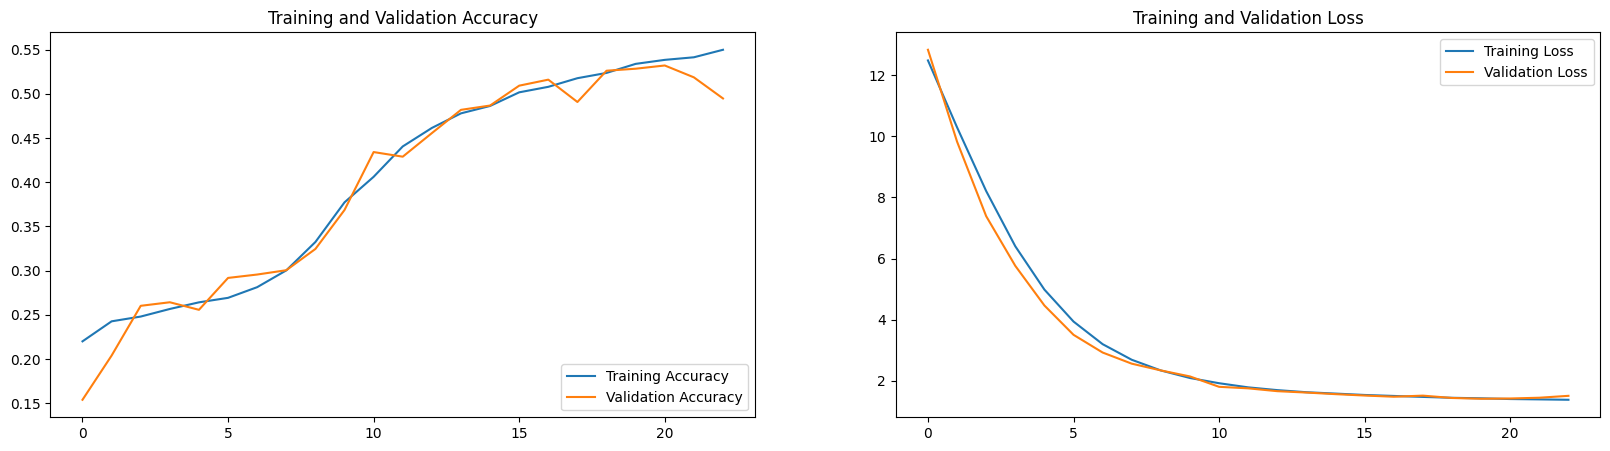

In [ ]:
plot_training_history(history)

In [ ]:
train_loss, train_accu = model.evaluate(train_generator)
test_loss, test_accu = model.evaluate(test_generator)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_accu*100, test_accu*100))

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.5431 - loss: 1.3719
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.5304 - loss: 1.4069
final train accuracy = 54.31 , validation accuracy = 53.04


113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step


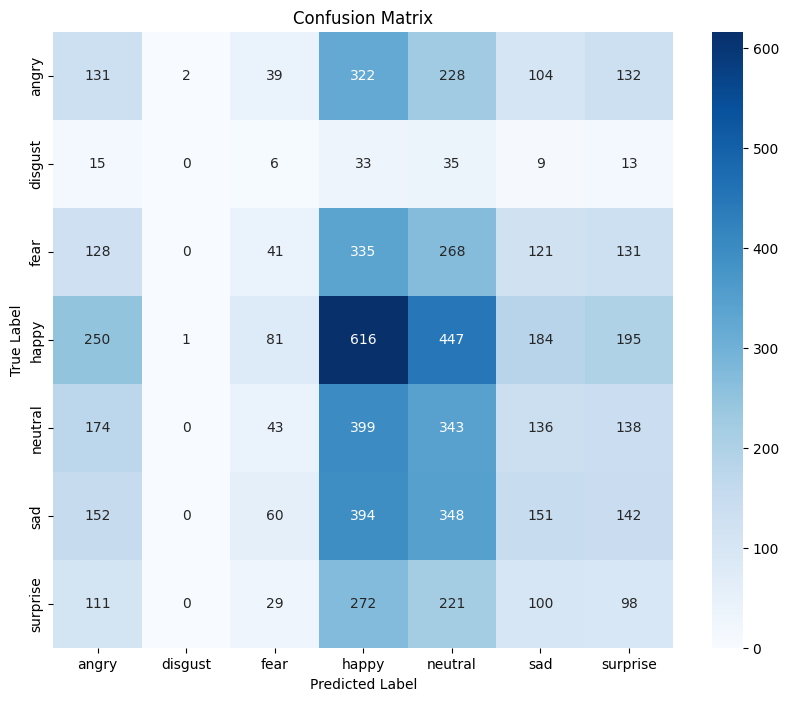

In [ ]:
# Assuming our true_classes and predicted_classes are already defined
true_classes = test_generator.classes
predicted_classes = np.argmax(
    model.predict(test_generator, steps=len(test_generator)),
    axis=1
)

# Generate the confusion matrix
cm = confusion_matrix(true_classes,predicted_classes)

# Ploting with seaborn
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_labels,yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [ ]:
# Printing the classification report
report = classification_report(true_classes,
                               predicted_classes,
                               target_names=class_labels,
                               zero_division=0)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       angry       0.14      0.14      0.14       958
     disgust       0.00      0.00      0.00       111
        fear       0.14      0.04      0.06      1024
       happy       0.26      0.35      0.30      1774
     neutral       0.18      0.28      0.22      1233
         sad       0.19      0.12      0.15      1247
    surprise       0.12      0.12      0.12       831

    accuracy                           0.19      7178
   macro avg       0.15      0.15      0.14      7178
weighted avg       0.18      0.19      0.18      7178



# **Model 3: Transfer Learning VGGNET**

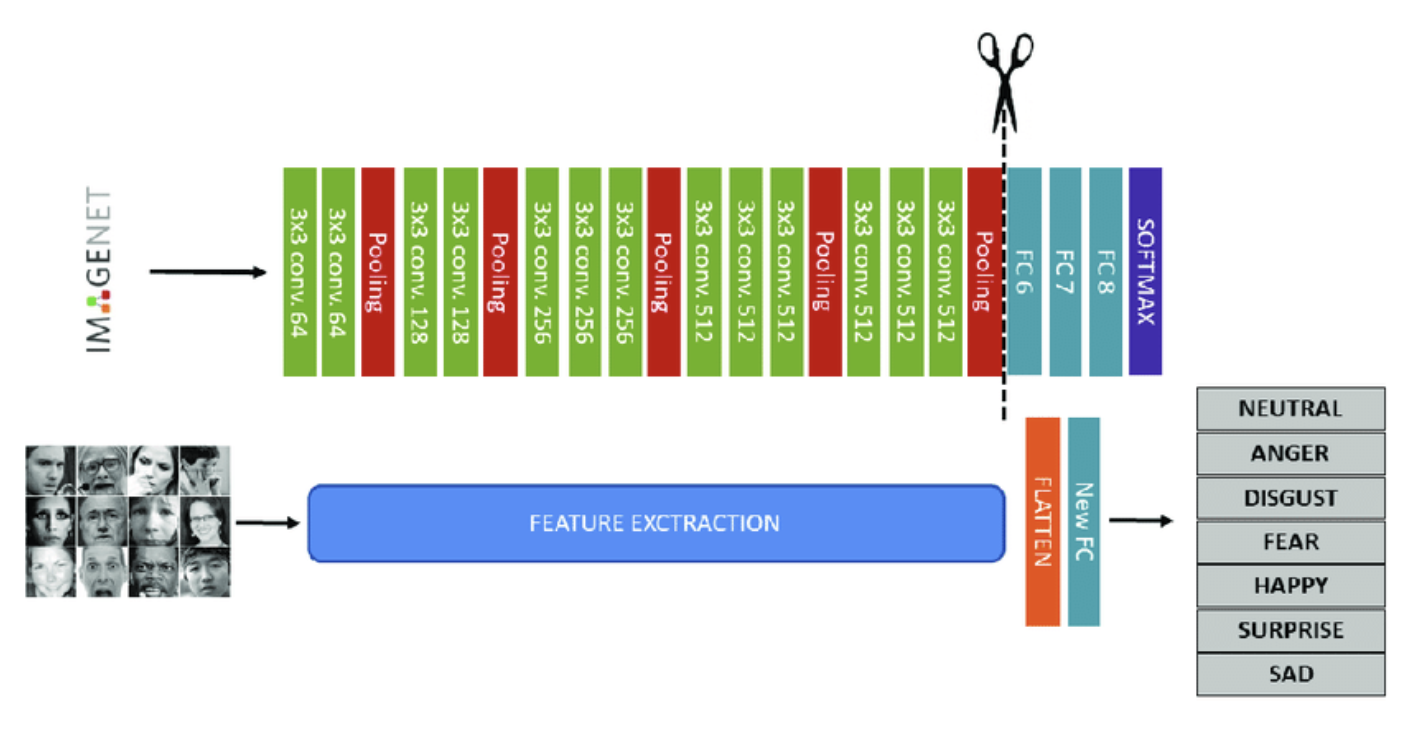

In [ ]:
 # Define path to the train and test directories
train_data_dir = '/content/train'
test_data_dir = '/content/test'

# Set Some Parameters
img_width,img_height = 224,224 # reshape the image in (224,224)
batch_size = 64
epochs = 10
num_classes = 7

# Initializing the ImageDataGenerator with data augmentation options for the training set
data_generator = ImageDataGenerator(
    rescale = 1./255,         # Rescale the pixel values from [0,255] to [0.1]
    rotation_range = 10,      # Degree range for random rotations
    width_shift_range = 0.1,  # Range (as a fractions of total width) for random horizontal shifts
    height_shift_range = 0.1, # Range (as a fraction of total height) for random vertical shifts
    horizontal_flip = True,   # Randomly flip inputs horizontally
    fill_mode = 'nearest'     # Strategy to fill newly created pixels, which can appear after a rotation or a width/height shift
)


test_preprocessor = ImageDataGenerator(
    rescale = 1/255.
)

# Automatically retrieve images and their classes for train sets
train_generator = data_generator.flow_from_directory(
    train_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',
    color_mode = 'rgb',
    subset = 'training',
    shuffle = True
)


test_generator = test_preprocessor.flow_from_directory(
    test_data_dir,
    target_size = (img_width,img_height),
    batch_size = batch_size,
    class_mode = 'categorical',
    color_mode = 'rgb'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
train_generator.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [ ]:
# Exttract class labels for all instancesw in the training dataset
classes = np.array(train_generator.classes)

# Calculate class weights to handle imbalances in the training data
# 'Balances' mode automatically adjusts weights inversely proprotional to class frequencies
class_weights = compute_class_weight(
    class_weight='balanced',  # Strategy to balance classes
    classes = np.unique(classes),   # Unique class labels
    y = classes  # Class labels for each instance in the training dataset

)


# Create a dictionary mapping class indeces to their calculated weights
class_weights_dict = dict(enumerate(class_weights))

# Output the class weights dictionary
print("Class Weights Dictionary : ",class_weights_dict)

Class Weights Dictionary :  {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [ ]:
classes = 7

# Clear the previous Tensorflow sessionx
tf.keras.backend.clear_session()

# Load the 'VGG16' base model, excluding its TOP(fully connected) Layers
vgg = VGG16(input_shape=(224,224,3),include_top=False,weights='imagenet')
vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
vgg.layers

[<InputLayer name=input_layer, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [ ]:
# Make the specified layers non-trainable
for layer in vgg.layers[:-3]:  # # all layers except the last three
    layer.trainable = False


vgg.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 4,719,616 (18.00 MB)

 Non-trainable params: 9,995,072 (38.13 MB)

In [ ]:
# Flattening the layer and edding custom Dense Layers
x = Flatten()(vgg.output)

# Adding a fully  connected layer with ReLU acctivation and He-normal initializer
x = Dense(1024,activation='relu',kernel_initializer='he_normal')(x)
x = Dropout(0.5)(x)   # Adding dropout for regularization

x = Dense(512,activation='relu',kernel_initializer='he_normal')(x)
x = Dropout(0.5)(x)

# Adding the output layer with softmax activation
# Note : Adjust the number of units to match the number of classes we have
output = Dense(classes, activation='softmax',kernel_initializer='he_normal')(x)


# Creating the model
model = Model(inputs = vgg.input,outputs = output)

# Compil the model
model.compile(loss = 'categorical_crossentropy',
              optimizer = tf.optimizers.Adam(learning_rate=0.0001,beta_1=0.9,beta_2=0.999,amsgrad=False),
              metrics = ['accuracy']
)


# Model summary to see all layers
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         3,59

 Total params: 40,934,215 (156.15 MB)

 Trainable params: 30,939,143 (118.02 MB)

 Non-trainable params: 9,995,072 (38.13 MB)

In [ ]:
# File path for the model checkpoint
cnn_path = '/content/FER_2013_Emotion_Dection_using_Transfer_Learning/VGG16_Transfer_Learning'
name = 'VGG16_Transfer_Learning.keras'
chk_path = os.path.join(cnn_path, name)

# Callback to save the model checkpoint
checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

# Callback for early stopping
earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=3,
                          verbose=1,
                          restore_best_weights=True)

# Callback to reduce learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=6,
                              verbose=1,
                              min_delta=0.0001)

# Callback to log training data to a CSV file
csv_logger = CSVLogger(os.path.join(cnn_path,'training.log'))

# Aggregating all callbacks into a list
callbacks = [checkpoint, earlystop, reduce_lr, csv_logger]  # Adjusted as per your use-case

train_steps_per_epoch = train_generator.samples // train_generator.batch_size + 1
# validation_steps_epoch = validation_generator.samples // validation_generator.batch_size + 1
test_steps_epoch = test_generator.samples // test_generator.batch_size + 1

In [ ]:
history = model.fit(train_generator,
                    steps_per_epoch=train_steps_per_epoch,
                    validation_data=test_generator,
                    validation_steps=test_steps_epoch,
                    epochs=50,
                    callbacks = callbacks)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 970ms/step - accuracy: 0.3206 - loss: 1.7362
Epoch 1: val_loss improved from None to 1.28663, saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/VGG16_Transfer_Learning/VGG16_Transfer_Learning.keras

Epoch 1: finished saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/VGG16_Transfer_Learning/VGG16_Transfer_Learning.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 508s 1s/step - accuracy: 0.3989 - loss: 1.5409 - val_accuracy: 0.5086 - val_loss: 1.2866 - learning_rate: 1.0000e-04
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.4919 - loss: 1.3377
Epoch 2: val_loss improved from 1.28663 to 1.22179, saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/VGG16_Transfer_Learning/VGG16_Transfer_Learning.keras

Epoch 2: finished saving model to /content/FER_2013_Emotion_Dection_using_Transfer_Learning/VGG16_Transfer_Learning/VGG16_Transfer_Learning.keras
449/449 ━━━━━━━━━━━━━━━━━━━

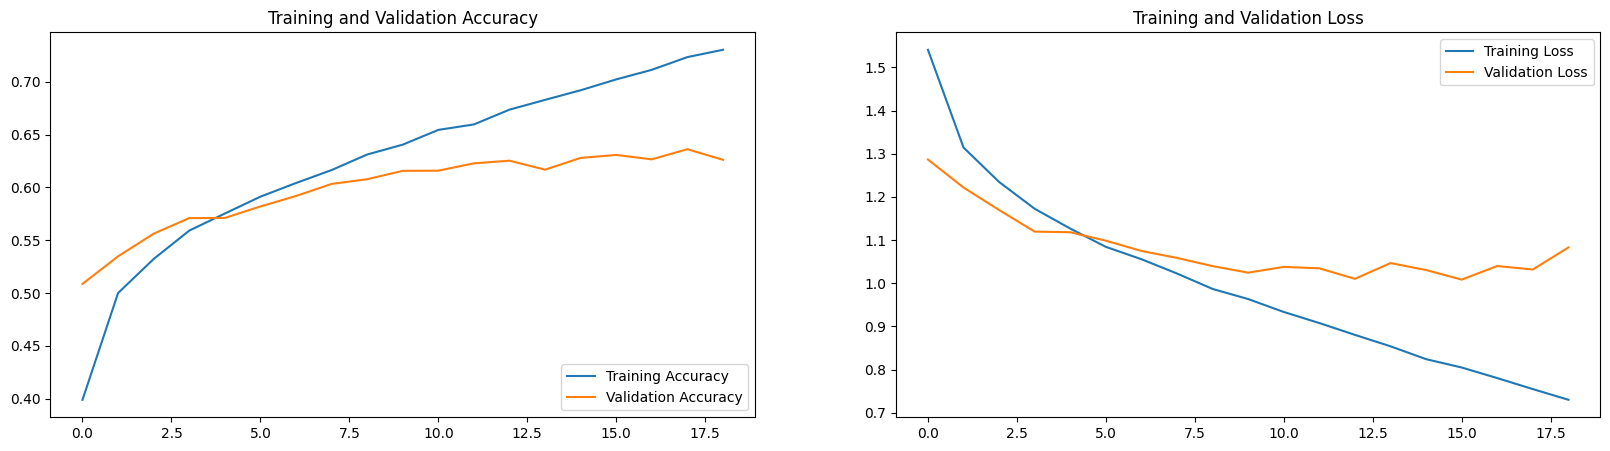

In [ ]:
plot_training_history(history)

In [ ]:
train_loss, train_accu = model.evaluate(train_generator)
test_loss, test_accu = model.evaluate(test_generator)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_accu*100, test_accu*100))

449/449 ━━━━━━━━━━━━━━━━━━━━ 419s 932ms/step - accuracy: 0.7430 - loss: 0.7021
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 291ms/step - accuracy: 0.6307 - loss: 1.0084
final train accuracy = 74.30 , validation accuracy = 63.07


113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 293ms/step


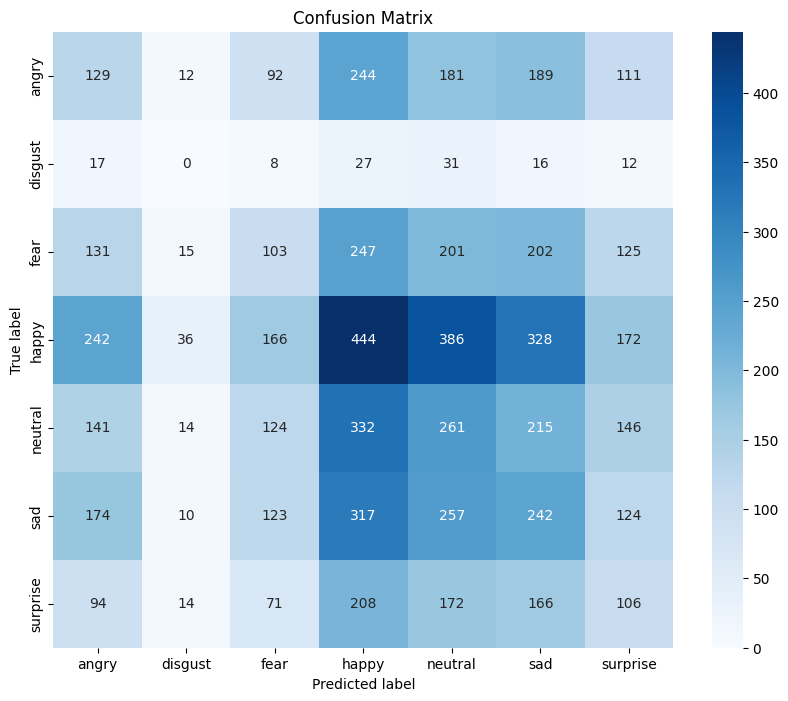

In [ ]:
true_classes = test_generator.classes

predicted_classes = np.argmax(
    model.predict(test_generator),
    axis=1
)

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


In [ ]:
# Printing the classification report
report = classification_report(true_classes,
                               predicted_classes,
                               target_names=class_labels,
                               zero_division=0)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       angry       0.14      0.13      0.14       958
     disgust       0.00      0.00      0.00       111
        fear       0.15      0.10      0.12      1024
       happy       0.24      0.25      0.25      1774
     neutral       0.18      0.21      0.19      1233
         sad       0.18      0.19      0.19      1247
    surprise       0.13      0.13      0.13       831

    accuracy                           0.18      7178
   macro avg       0.15      0.15      0.14      7178
weighted avg       0.18      0.18      0.18      7178



# **Model 4 : Transfer Leanring - ResNet50**

In [ ]:
train_dir = '/content/train'
test_dir = '/content/test'

# Data augmentation configuration for training data
train_datagen = ImageDataGenerator(rescale=1/255,                # Rescale pixel values to [0, 1]
                                  rotation_range=40,            # Randomly rotate images in the range (degrees, 0 to 180)
                                  width_shift_range=0.2,        # Randomly horizontally shift images
                                  height_shift_range=0.2,       # Randomly vertically shift images
                                  shear_range=0.2,              # Apply shearing transformations
                                  zoom_range=0.1,               # Randomly zoom image
                                  horizontal_flip=True,         # Randomly flip images horizontally
                                  fill_mode='nearest'           # Strategy used for filling in newly created pixels
                                )

# Rescaling for validation/test data (without further data augmentation)
test_datagen = ImageDataGenerator(
                                  rescale=1/255                 # Rescale pixel values to [0, 1]
                              )

# Creating data generators for training
train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(224, 224),       # Resize images to 224x224 for model input
                                                    color_mode='rgb',             # Images will be converted to RGB
                                                    class_mode='categorical',     # For multi-class classification
                                                    batch_size=32                 # Size of the batches of data
                                                )

# Creating data generators for testing/validation
test_generator = test_datagen.flow_from_directory(
                                                  test_dir,
                                                  target_size=(224, 224),       # Resize images to 224x224 for model input
                                                  color_mode='rgb',             # Images will be converted to RGB
                                                  class_mode='categorical',     # For multi-class classification
                                                  batch_size=32                 # Size of the batches of data
                                              )

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


### Class wieghts for imbalanced data

In [ ]:
print("Class Weights Dictionary:", class_weights_dict)

Class Weights Dictionary: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [ ]:
input_shape = (224, 224, 3)

base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=input_shape)

model = Sequential([
                    base_model,
                    BatchNormalization(),
                    GlobalAveragePooling2D(),
                    Dense(512, activation='relu'),
                    Dropout(0.1),
                    Dense(256, activation='relu'),
                    Dropout(0.1),
                    Dense(128, activation='relu'),
                    Dropout(0.1),
                    Dense(7, activation='softmax')
                  ])

optimizer = Adamax(learning_rate=0.0001)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 2048)     │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,787,207 (94.56 MB)

 Trainable params: 24,737,671 (94.37 MB)

 Non-trainable params: 49,536 (193.50 KB)

In [ ]:
# File path for the model checkpoint
cnn_path = '//content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning'
name = 'ResNet50_Transfer_Learning.keras'
chk_path = os.path.join(cnn_path, name)

# Callback to save the model checkpoint
checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

# Callback for early stopping
earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=6,
                          verbose=1,
                          restore_best_weights=True)

# Callback to reduce learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=6,
                              verbose=1,
                              min_delta=0.0001)

# Callback to log training data to a CSV file
csv_logger = CSVLogger(os.path.join(cnn_path,'training.log'))

# Aggregating all callbacks into a list
callbacks = [checkpoint, earlystop, csv_logger]  # Adjusted as per your use-case

train_steps_per_epoch = train_generator.samples // train_generator.batch_size + 1
# validation_steps_epoch = validation_generator.samples // validation_generator.batch_size + 1
test_steps_epoch = test_generator.samples // test_generator.batch_size + 1

In [ ]:
train_history = model.fit(
                          train_generator,
                          steps_per_epoch=200,
                          epochs=50,
                          validation_data=test_generator,
                          validation_steps=100,
                          class_weight=class_weights_dict,
                          callbacks = callbacks
                        )

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.1566 - loss: 1.8914
Epoch 1: val_loss improved from None to 1.83804, saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras

Epoch 1: finished saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 181s 587ms/step - accuracy: 0.2000 - loss: 1.9022 - val_accuracy: 0.2669 - val_loss: 1.8380
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.2608 - loss: 1.8207
Epoch 2: val_loss improved from 1.83804 to 1.74484, saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras

Epoch 2: finished saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras
200/200 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 5: val_loss improved from 1.53308 to 1.45795, saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras

Epoch 5: finished saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 56s 282ms/step - accuracy: 0.3804 - loss: 1.5933 - val_accuracy: 0.4563 - val_loss: 1.4580
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.4028 - loss: 1.5540
Epoch 6: val_loss improved from 1.45795 to 1.41893, saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras

Epoch 6: finished saving model to //content/FER_2013_Emotion_Dection_using_Transfer_Learning/ResNet50_Transfer_Learning/ResNet50_Transfer_Learning.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 115s 575ms/step - accuracy: 0.4075 - loss: 1.5486 - val_accuracy: 0.4734 - val_l

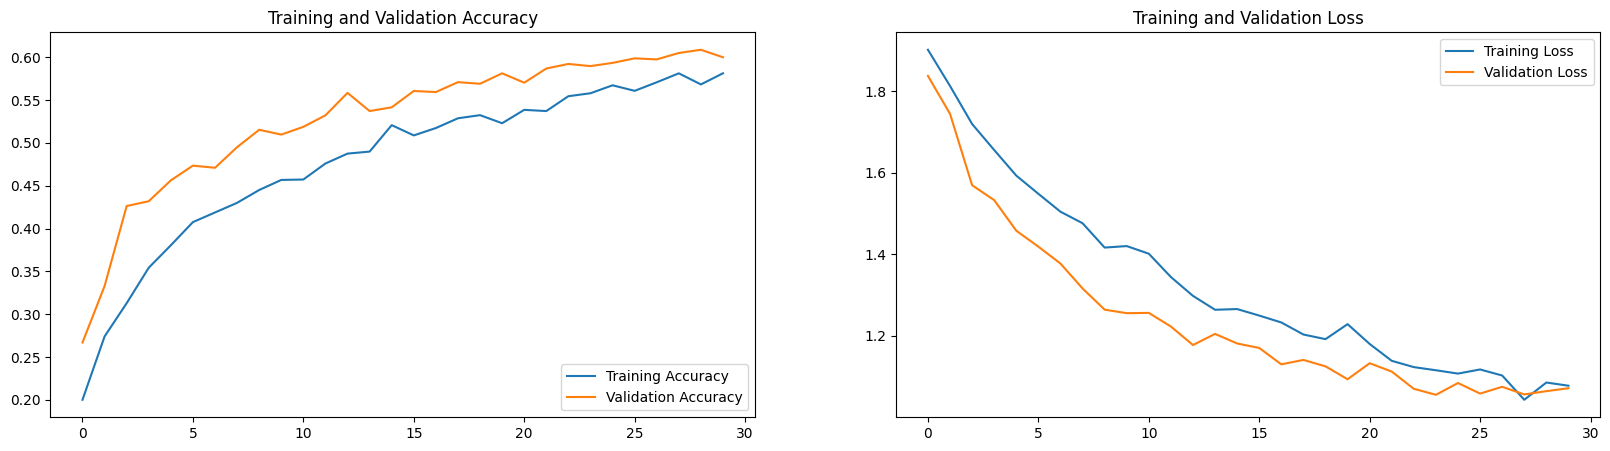

In [ ]:
plot_training_history(train_history)

In [ ]:
train_loss, train_accu = model.evaluate(train_generator)
test_loss, test_accu = model.evaluate(test_generator)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_accu*100, test_accu*100))

898/898 ━━━━━━━━━━━━━━━━━━━━ 402s 448ms/step - accuracy: 0.5855 - loss: 1.0809
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.5876 - loss: 1.0779
final train accuracy = 58.55 , validation accuracy = 58.76


225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 93ms/step


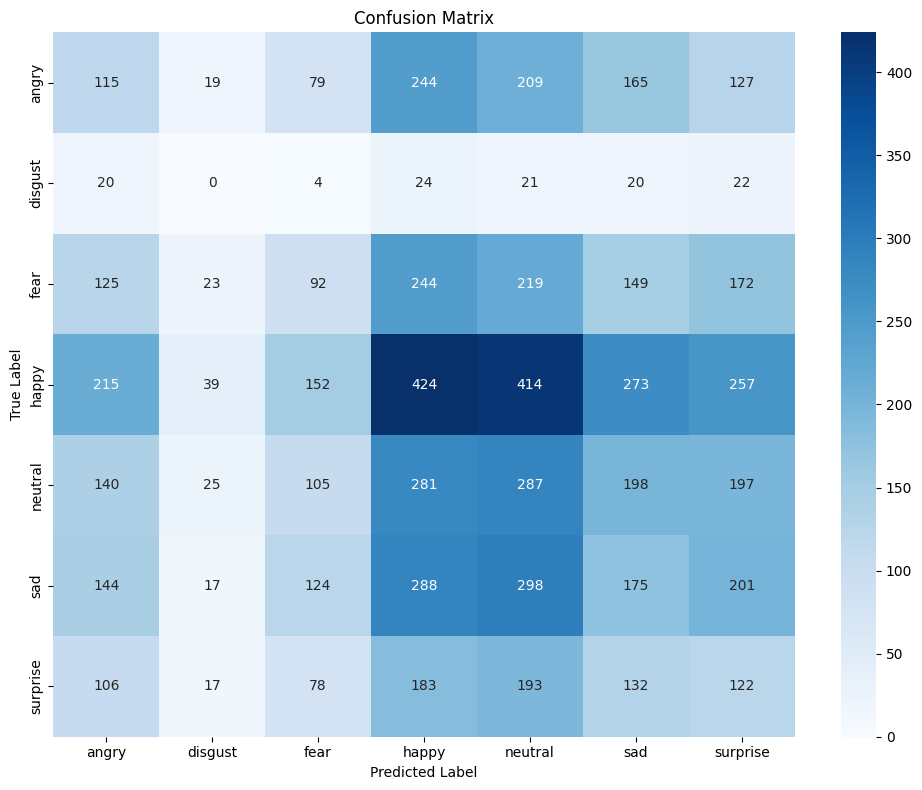

In [ ]:
# True class labels
true_classes = test_generator.classes

# Predict classes (Keras will infer steps automatically)
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Class label names
class_labels = list(test_generator.class_indices.keys())

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:
# Printing the classification report
report = classification_report(true_classes,
                               predicted_classes,
                               target_names=class_labels,
                               zero_division=0)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       angry       0.13      0.12      0.13       958
     disgust       0.00      0.00      0.00       111
        fear       0.15      0.09      0.11      1024
       happy       0.25      0.24      0.24      1774
     neutral       0.17      0.23      0.20      1233
         sad       0.16      0.14      0.15      1247
    surprise       0.11      0.15      0.13       831

    accuracy                           0.17      7178
   macro avg       0.14      0.14      0.14      7178
weighted avg       0.17      0.17      0.17      7178



# Push all your models into Drive for easy access.

In [ ]:
!cp -r /content/FER_2013_Emotion_Dection_using_Transfer_Learning /content/drive/MyDrive/PROJECTS/Emotion-Detection-using-Transfer-Learning